<a href="https://colab.research.google.com/github/kyliesutton/Kylie_Sutton_INFO4670_Spring2026/blob/main/kns0276_Term_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [27]:
#Please write the code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from google.colab import drive
drive.mount('/content/drive')
uploaded = "/content/drive/MyDrive/car_purchase_data.csv"
dataset = pd.read_csv(uploaded)

print(dataset.head())
print(dataset.info())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    User ID  Gender  Age  Salary  Purchased
0  15624510    Male   19   19000          0
1  15810944    Male   35   20000          0
2  15668575  Female   26   43000          0
3  15603246  Female   27   57000          0
4  15804002    Male   19   76000          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   User ID    400 non-null    int64 
 1   Gender     400 non-null    object
 2   Age        400 non-null    int64 
 3   Salary     400 non-null    int64 
 4   Purchased  400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


### Step 2: Split features and target

In [21]:
#Please write the code here
X = dataset[['Age', 'Salary']].values
y = dataset['Purchased'].values

### Step 3: Train/Test Split

In [22]:
#Please write the code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

### Step 4: Feature Scaling

In [23]:
#Please write the code here
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Step 5: Train Logistic Regression Model

In [24]:
#Please write the code here
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

### Step 6: Predict and Evaluate

In [25]:
#Please write the code here
y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(matrix)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.89
Confusion Matrix:
[[65  3]
 [ 8 24]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



### Step 7: Visualization of Decision Regions

/tmp/ipykernel_10486/140106926.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c=ListedColormap(('black', 'white')) (i), label=j)


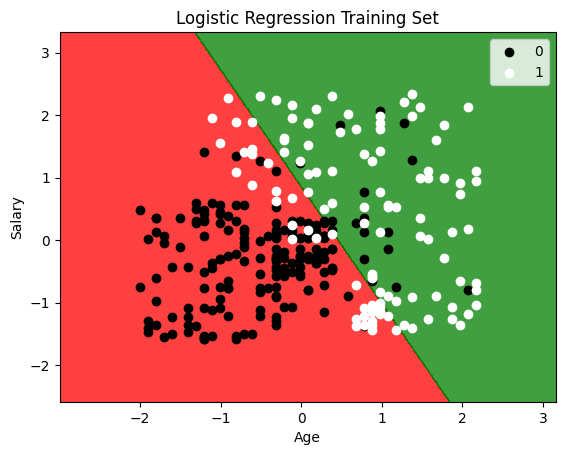

In [31]:
#Please write the code here
X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75, cmap=ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c=ListedColormap(('black', 'white')) (i), label=j)

plt.title('Logistic Regression Training Set')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.legend()
plt.show()

Background Colors (decision surface):
  Red Region: did not purchase
  Green Region: purchased

Dots (classes):
  0 = did not purchase
  1 = purchased

Standardized Age:
  -2 = below average
  0 = average
  3 = above average

Standardized Salary:
  -2 = below average
  0 = average
  3 = above average

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. Logistic regression can still be used for classification because it uses probabilities based off the sigmoid function. These probabilities can be mapped into class labels by applying a threshold. If the probability is greater than, or eaqual to 0.5 then it predicts class 1, otherwise it predicts class 0. Logistic regression is good for classification in relation to binary classes.
2. Based on the above graph, those most likely to purchase a car are above the average age and make an average, or above average salary.
3. In this task some potential factors that could cause lower accuracy include the size of the dataset. It is also highly likely that several other factors go into the decision of purchasing a car other than just age and salary.
4. Some potential features that could be added to improve accuracy could be things like credit score and location. These would be good features to add because, in real life, they often have a large influence on the likelihood of a person purchasing a car. Those with low credit score or live in an area like New York City are going to be less likely to purchase a car. The dataset also already has gender included, meaning there could be more information we could learn by including gender as a feature.